# Proyecto 2 – Modelos Predictivos
## Defunciones en Guatemala 2011–2021
### CC3074 – Minería de Datos | Grupo 7
**Variable respuesta:** `asis_med` — Asistencia médica (Sí / No)  
**Tipo de problema:** Clasificación binaria  
**Algoritmos:** Árbol de Decisión · Random Forest · Regresión Logística


## 1. Librerías y configuración

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, accuracy_score)

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 2. Carga y consolidación de datos
Los archivos CSV corresponden a los registros de defunciones del INE Guatemala 2011–2021.
Ajusta la ruta `DATA_PATH` al directorio donde están tus archivos.


In [39]:
# ─── OPCIÓN A: CSV limpio exportado desde el RMD (recomendado) ───────────────
CSV_PATH = "datos_limpios_proyecto1.csv"   # <-- ajusta la ruta si es necesario

datos_raw = pd.read_csv(CSV_PATH, encoding="utf-8", low_memory=False)
datos_raw.columns = datos_raw.columns.str.lower().str.strip()
print(f"✅ Datos cargados: {datos_raw.shape[0]:,} filas × {datos_raw.shape[1]} columnas")
datos_raw.head(3)

# ─── OPCIÓN B: múltiples CSVs originales (descomenta si no tienes el CSV limpio) ─
# DATA_PATH = "./"
# archivos = glob.glob(DATA_PATH + "*.csv")
# dfs = [pd.read_csv(f, dtype=str, encoding="latin-1", low_memory=False) for f in archivos]
# datos_raw = pd.concat(dfs, ignore_index=True)
# datos_raw.columns = datos_raw.columns.str.lower().str.strip()


✅ Datos cargados: 809,292 filas × 37 columnas


,x1,depreg,mupreg,mesreg,anoreg,depocu,mupocu,areag,sexo,diaocu,...,mupreg_2,mupocu_2,pnadif,predif,puedif,ciuodif,caudef_descrip,anoocu_2,edad_anios,causa_capitulo
0,0,PETEN,SAN ANDRES,NaN,2011,PETEN,SAN ANDRES,RURAL,HOMBRE,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,W
1,1,GUATEMALA,MIXCO,NaN,2011,GUATEMALA,MIXCO,URBANO,HOMBRE,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,W
2,2,GUATEMALA,GUATEMALA,NaN,2011,GUATEMALA,GUATEMALA,URBANO,HOMBRE,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,R


## 3. Limpieza y transformación
Se replican las transformaciones del EDA anterior más las necesarias para ML.


In [40]:
import unicodedata

def quitar_tildes(s):
    if not isinstance(s, str):
        return s
    return "".join(c for c in unicodedata.normalize("NFD", s)
                   if unicodedata.category(c) != "Mn")

# Estandarizar texto — todo en una lambda, sin .str.upper() sobre NaN
for col in datos_raw.select_dtypes(include="object").columns:
    datos_raw[col] = datos_raw[col].apply(
        lambda x: quitar_tildes(x).upper().strip() if isinstance(x, str) else x
    )

# Convertir numéricas
for col in ["anoreg", "mesreg", "diaocu", "edadif"]:
    if col in datos_raw.columns:
        datos_raw[col] = pd.to_numeric(datos_raw[col], errors="coerce")

# Edad en años (solo si no viene ya calculada del CSV limpio)
if "edad_anios" not in datos_raw.columns:
    def edad_en_anios(row):
        p = str(row.get("perdif", "")).upper()
        e = row.get("edadif", np.nan)
        if pd.isna(e):
            return np.nan
        if "ANO" in p or "ANO" in p:
            return e
        if "MES" in p:
            return e / 12
        if "DIA" in p:
            return e / 365
        if "HORA" in p:
            return e / 8760
        return np.nan
    datos_raw["edad_anios"] = datos_raw.apply(edad_en_anios, axis=1)

# Capítulo CIE-10 (solo si no viene del CSV limpio)
if "causa_capitulo" not in datos_raw.columns and "caudef" in datos_raw.columns:
    datos_raw["causa_capitulo"] = datos_raw["caudef"].str[:1]

# Filtrar edades imposibles
datos = datos_raw[datos_raw["edad_anios"].isna() | (datos_raw["edad_anios"] <= 115)].copy()
print(f"Registros tras limpieza: {len(datos):,}")
print(f"Columnas disponibles: {datos.columns.tolist()}")


Registros tras limpieza: 809,292
Columnas disponibles: ['x1', 'depreg', 'mupreg', 'mesreg', 'anoreg', 'depocu', 'mupocu', 'areag', 'sexo', 'diaocu', 'mesocu', 'anoocu', 'edadif', 'perdif', 'getdif', 'ecidif', 'escodif', 'ocudif', 'dnadif', 'mnadif', 'nacdif', 'dredif', 'mredif', 'caudef', 'asist', 'ocur', 'cerdef', 'mupreg_2', 'mupocu_2', 'pnadif', 'predif', 'puedif', 'ciuodif', 'caudef_descrip', 'anoocu_2', 'edad_anios', 'causa_capitulo']


## 4. Variable respuesta: `asis_med`
**Justificación:** Predecir si una persona recibió asistencia médica antes de fallecer es
relevante para identificar brechas de acceso al sistema de salud en Guatemala.
Es una variable **cualitativa binaria** (Sí / No), por lo que se aborda como clasificación.


In [41]:
# Ver columnas disponibles relacionadas con asistencia
asist_cols = [c for c in datos.columns if 'asis' in c.lower()]
print("Columnas relacionadas con asistencia:", asist_cols)
print(datos.columns.tolist())


Columnas relacionadas con asistencia: ['asist']
['x1', 'depreg', 'mupreg', 'mesreg', 'anoreg', 'depocu', 'mupocu', 'areag', 'sexo', 'diaocu', 'mesocu', 'anoocu', 'edadif', 'perdif', 'getdif', 'ecidif', 'escodif', 'ocudif', 'dnadif', 'mnadif', 'nacdif', 'dredif', 'mredif', 'caudef', 'asist', 'ocur', 'cerdef', 'mupreg_2', 'mupocu_2', 'pnadif', 'predif', 'puedif', 'ciuodif', 'caudef_descrip', 'anoocu_2', 'edad_anios', 'causa_capitulo']


Distribución asis_med_bin:
asis_med_bin
0    407289
1    402003
Name: count, dtype: int64


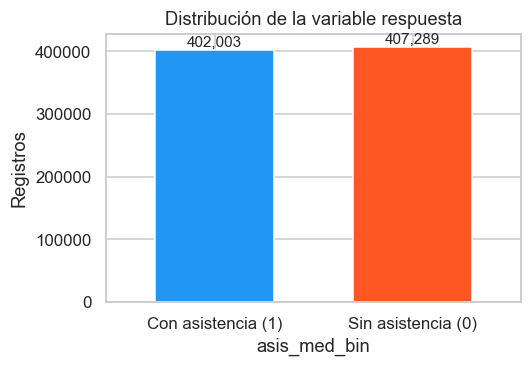


Clase 1 (Con asistencia): 49.7%
Clase 0 (Sin asistencia): 50.3%


In [42]:
# Binarizar desde columna 'asist':
# 1 = Recibió algún tipo de asistencia (MEDICA, PARAMEDICA, EMPIRICA, COMADRONA)
# 0 = Sin asistencia o desconocido (NINGUNA, IGNORADO)

con_asistencia = {'MEDICA', 'PARAMEDICA', 'EMPIRICA', 'COMADRONA'}

datos['asis_med_bin'] = datos['asist'].apply(
    lambda x: 1 if isinstance(x, str) and x.strip().upper() in con_asistencia else
              (0 if isinstance(x, str) else np.nan)
)

conteo = datos['asis_med_bin'].value_counts()
print("Distribución asis_med_bin:")
print(conteo)

fig, ax = plt.subplots(figsize=(5, 3.5))
conteo.reindex([1, 0]).plot(kind="bar", ax=ax, color=["#2196F3", "#FF5722"],
                             edgecolor="white", width=0.6)
ax.set_xticklabels(["Con asistencia (1)", "Sin asistencia (0)"], rotation=0)
ax.set_title("Distribución de la variable respuesta")
ax.set_ylabel("Registros")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

pct = conteo / conteo.sum() * 100
print(f"\nClase 1 (Con asistencia): {pct.get(1, 0):.1f}%")
print(f"Clase 0 (Sin asistencia): {pct.get(0, 0):.1f}%")

## 5. Preprocesamiento para ML
Se seleccionan las variables predictoras más relevantes del EDA anterior y se codifican.


In [43]:
# Variables predictoras disponibles
FEATURES_CAT = []
FEATURES_NUM = []

# Nombres reales de tu dataset
candidatas_cat = ['sexo', 'areag', 'depocu', 'depreg', 'ocur', 'causa_capitulo', 'mesreg', 'perdif']
candidatas_num = ['edad_anios', 'anoreg']

for c in candidatas_cat:
    if c in datos.columns:
        FEATURES_CAT.append(c)

for c in candidatas_num:
    if c in datos.columns:
        FEATURES_NUM.append(c)

print("Variables categóricas a usar:", FEATURES_CAT)
print("Variables numéricas a usar  :", FEATURES_NUM)

Variables categóricas a usar: ['sexo', 'areag', 'depocu', 'depreg', 'ocur', 'causa_capitulo', 'mesreg', 'perdif']
Variables numéricas a usar  : ['edad_anios', 'anoreg']


In [46]:
# Construir dataframe de modelado
TARGET = 'asis_med_bin'

# Quitar columnas con demasiados nulos antes de definir features
candidatas_cat = ['sexo', 'depocu', 'depreg', 'ocur', 'causa_capitulo', 'perdif']
candidatas_num = ['edad_anios', 'anoreg']

# Solo incluir columnas con menos del 30% de nulos
umbral = 0.30 * len(datos)
FEATURES_CAT = [c for c in candidatas_cat if c in datos.columns and datos[c].isnull().sum() < umbral]
FEATURES_NUM = [c for c in candidatas_num if c in datos.columns and datos[c].isnull().sum() < umbral]
FEATURES = FEATURES_NUM + FEATURES_CAT

print("Features numéricas:", FEATURES_NUM)
print("Features categóricas:", FEATURES_CAT)
print(f"Registros antes de dropna: {len(datos):,}")

df_model = datos[FEATURES + [TARGET]].dropna().copy()
print(f"Registros para modelado: {len(df_model):,}")

# Codificar categóricas
le_dict = {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Escalar numéricas
scaler = StandardScaler()
df_model_scaled = df_model.copy()
if FEATURES_NUM:
    df_model_scaled[FEATURES_NUM] = scaler.fit_transform(df_model[FEATURES_NUM])

X    = df_model[FEATURES].values
y    = df_model[TARGET].values.astype(int)
X_sc = df_model_scaled[FEATURES].values

print(f"\nShape X: {X.shape} | Shape y: {y.shape}")
print(f"Balance → Clase 1: {y.mean()*100:.1f}% | Clase 0: {(1-y.mean())*100:.1f}%")

Features numéricas: ['edad_anios', 'anoreg']
Features categóricas: ['sexo', 'depocu', 'depreg', 'ocur', 'causa_capitulo', 'perdif']
Registros antes de dropna: 809,292
Registros para modelado: 802,793

Shape X: (802793, 8) | Shape y: (802793,)
Balance → Clase 1: 49.7% | Clase 0: 50.3%


## 6. División entrenamiento / prueba
Se usa **70% entrenamiento – 30% prueba** con `stratify=y` para preservar el balance de clases.


In [47]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("FEATURES:", FEATURES)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_train_sc, X_test_sc, _, _ = train_test_split(
    X_sc, y, test_size=0.30, random_state=42, stratify=y)

print(f"Entrenamiento : {X_train.shape[0]:,} registros ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Prueba        : {X_test.shape[0]:,} registros ({X_test.shape[0]/len(y)*100:.0f}%)")
print(f"\nBalance en entrenamiento → Clase 1: {y_train.mean()*100:.1f}%")
print(f"Balance en prueba         → Clase 1: {y_test.mean()*100:.1f}%")


Shape X: (802793, 8)
Shape y: (802793,)
FEATURES: ['edad_anios', 'anoreg', 'sexo', 'depocu', 'depreg', 'ocur', 'causa_capitulo', 'perdif']
Entrenamiento : 561,955 registros (70%)
Prueba        : 240,838 registros (30%)

Balance en entrenamiento → Clase 1: 49.7%
Balance en prueba         → Clase 1: 49.7%


## 7. Funciones auxiliares de evaluación

In [48]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Imprime métricas y muestra matriz de confusión."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    cv   = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='accuracy').mean()

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy (test)  : {acc:.4f}")
    print(f"  AUC-ROC          : {auc:.4f}" if auc else "  AUC-ROC          : N/A")
    print(f"  CV-Accuracy (5k) : {cv:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Sin asist.','Con asist.'])}")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                           display_labels=['Sin asist.','Con asist.']).plot(ax=ax, colorbar=False,
                                                                            cmap='Blues')
    ax.set_title(f'Matriz de Confusión – {nombre}')
    plt.tight_layout()
    plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'auc': auc, 'cv_accuracy': cv,
            'fitted': modelo, 'y_pred': y_pred, 'y_prob': y_prob}

resultados = []
print("✅ Función de evaluación lista")


✅ Función de evaluación lista


## 8. Algoritmo 1: Árbol de Decisión
Se prueban distintas profundidades máximas para evitar sobreajuste.


In [49]:
# -- Barrido de parámetros --
profundidades = [3, 5, 7, 10, None]
res_dt = []
for d in profundidades:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, dt.predict(X_train))
    acc_te = accuracy_score(y_test,  dt.predict(X_test))
    res_dt.append({'max_depth': str(d), 'acc_train': acc_tr, 'acc_test': acc_te,
                   'diferencia': acc_tr - acc_te})

df_dt = pd.DataFrame(res_dt)
print(df_dt.to_string(index=False))


max_depth  acc_train  acc_test  diferencia
        3   0.848390  0.848035    0.000355
        5   0.864201  0.863730    0.000471
        7   0.869751  0.869448    0.000304
       10   0.872671  0.870934    0.001737
     None   0.933897  0.819597    0.114300


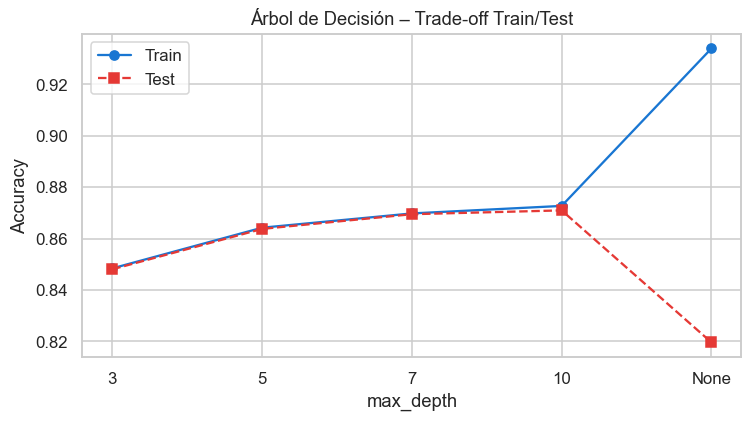

In [50]:
# Visualización del barrido
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_dt['max_depth'], df_dt['acc_train'], 'o-', label='Train', color='#1976D2')
ax.plot(df_dt['max_depth'], df_dt['acc_test'],  's--', label='Test',  color='#E53935')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Árbol de Decisión – Trade-off Train/Test')
ax.legend()
plt.tight_layout()
plt.show()



  Árbol de Decisión (depth=5)
  Accuracy (test)  : 0.8637
  AUC-ROC          : 0.9056
  CV-Accuracy (5k) : 0.8642

              precision    recall  f1-score   support

  Sin asist.       0.81      0.95      0.88    121130
  Con asist.       0.94      0.77      0.85    119708

    accuracy                           0.86    240838
   macro avg       0.88      0.86      0.86    240838
weighted avg       0.88      0.86      0.86    240838



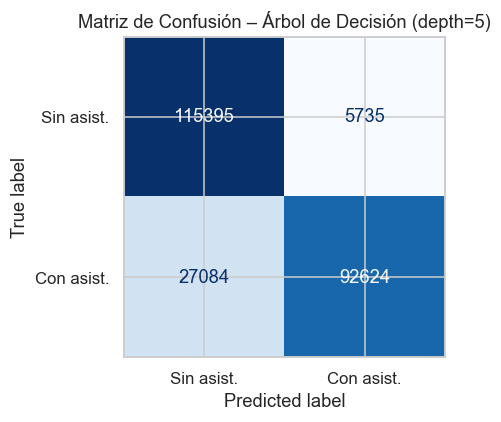

In [51]:
# -- Modelo final Árbol --
dt_final = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
r = evaluar_modelo('Árbol de Decisión (depth=5)', dt_final, X_train, y_train, X_test, y_test)
resultados.append(r)


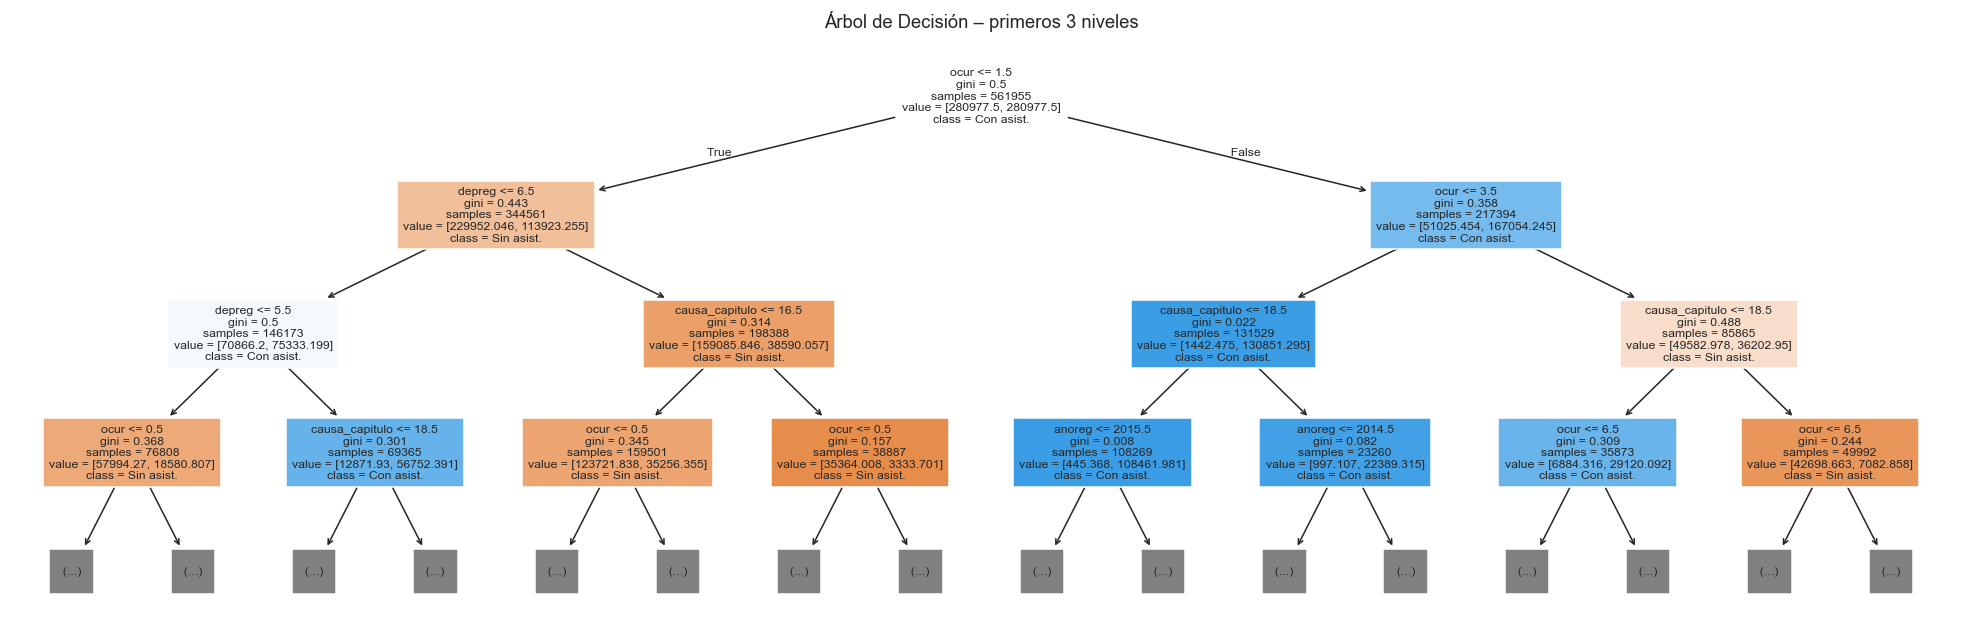

In [52]:
# Visualizar el árbol (primeros 3 niveles)
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt_final, max_depth=3, feature_names=FEATURES,
          class_names=['Sin asist.','Con asist.'],
          filled=True, fontsize=8, ax=ax)
plt.title('Árbol de Decisión – primeros 3 niveles')
plt.tight_layout()
plt.show()


## 9. Algoritmo 2: Random Forest
Se varía el número de árboles y la profundidad máxima para encontrar el mejor modelo.


In [53]:
# -- Barrido de parámetros --
param_grid_rf = {'n_estimators': [50, 100, 200],
                 'max_depth':    [5, 10, None]}

res_rf = []
for ne in param_grid_rf['n_estimators']:
    for md_ in param_grid_rf['max_depth']:
        rf = RandomForestClassifier(n_estimators=ne, max_depth=md_,
                                    random_state=42, class_weight='balanced', n_jobs=-1)
        rf.fit(X_train, y_train)
        acc_te = accuracy_score(y_test, rf.predict(X_test))
        auc_te = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
        res_rf.append({'n_estimators': ne, 'max_depth': str(md_),
                       'acc_test': acc_te, 'auc_test': auc_te})

df_rf = pd.DataFrame(res_rf).sort_values('auc_test', ascending=False)
print(df_rf.to_string(index=False))


 n_estimators max_depth  acc_test  auc_test
          100        10  0.868488  0.925634
          200        10  0.868580  0.925500
           50        10  0.867525  0.925066
          200      None  0.844572  0.909755
          100      None  0.843974  0.909228
           50      None  0.843442  0.908155
          200         5  0.850485  0.894797
           50         5  0.851012  0.892644
          100         5  0.850601  0.892456



  Random Forest (n=100, depth=10)
  Accuracy (test)  : 0.8685
  AUC-ROC          : 0.9256
  CV-Accuracy (5k) : 0.8675

              precision    recall  f1-score   support

  Sin asist.       0.82      0.94      0.88    121130
  Con asist.       0.93      0.79      0.86    119708

    accuracy                           0.87    240838
   macro avg       0.88      0.87      0.87    240838
weighted avg       0.88      0.87      0.87    240838



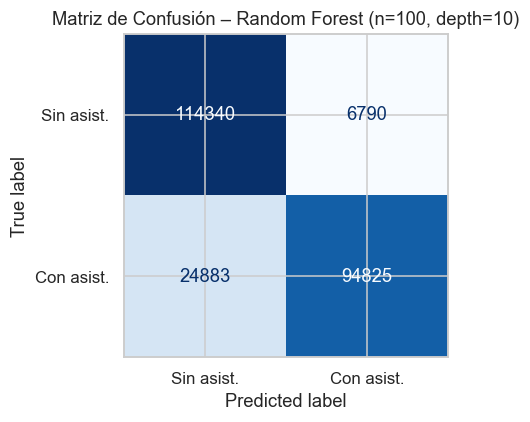

In [54]:
# -- Modelo final RF (mejores parámetros) --
best = df_rf.iloc[0]
rf_final = RandomForestClassifier(n_estimators=int(best['n_estimators']),
                                   max_depth=None if best['max_depth']=='None' else int(best['max_depth']),
                                   random_state=42, class_weight='balanced', n_jobs=-1)
r = evaluar_modelo(f"Random Forest (n={int(best['n_estimators'])}, depth={best['max_depth']})",
                   rf_final, X_train, y_train, X_test, y_test)
resultados.append(r)


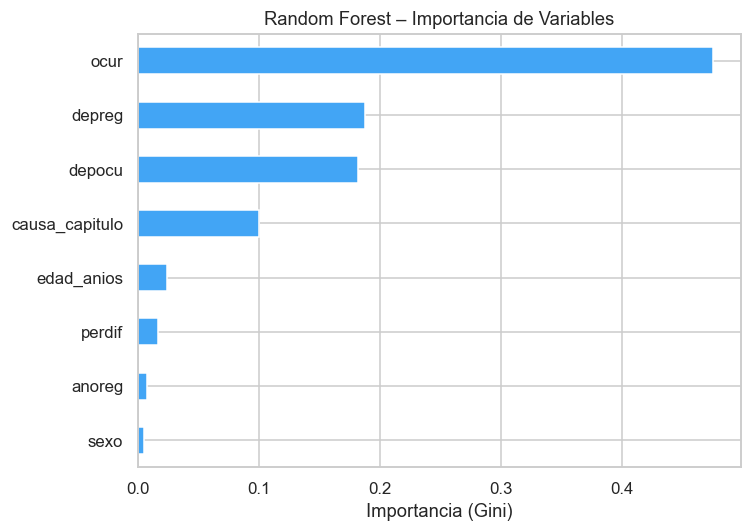

In [55]:
# Importancia de variables
importancias = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
importancias.plot(kind='barh', ax=ax, color='#42A5F5', edgecolor='white')
ax.set_title('Random Forest – Importancia de Variables')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()


## 10. Algoritmo 3: Regresión Logística
Se varía el parámetro de regularización `C`. Se usan las variables escaladas.


In [56]:
# -- Barrido de parámetros --
Cs = [0.01, 0.1, 1, 10, 100]
res_lr = []
for c_val in Cs:
    lr = LogisticRegression(C=c_val, max_iter=1000, random_state=42,
                            class_weight='balanced', solver='lbfgs')
    lr.fit(X_train_sc, y_train)
    acc_te = accuracy_score(y_test, lr.predict(X_test_sc))
    auc_te = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
    res_lr.append({'C': c_val, 'acc_test': acc_te, 'auc_test': auc_te})

df_lr = pd.DataFrame(res_lr)
print(df_lr.to_string(index=False))


     C  acc_test  auc_test
  0.01  0.632367  0.686857
  0.10  0.632409  0.686854
  1.00  0.632409  0.686854
 10.00  0.632409  0.686853
100.00  0.632409  0.686853



  Regresión Logística (C=0.01)
  Accuracy (test)  : 0.6324
  AUC-ROC          : 0.6869
  CV-Accuracy (5k) : 0.6322

              precision    recall  f1-score   support

  Sin asist.       0.63      0.65      0.64    121130
  Con asist.       0.63      0.62      0.62    119708

    accuracy                           0.63    240838
   macro avg       0.63      0.63      0.63    240838
weighted avg       0.63      0.63      0.63    240838



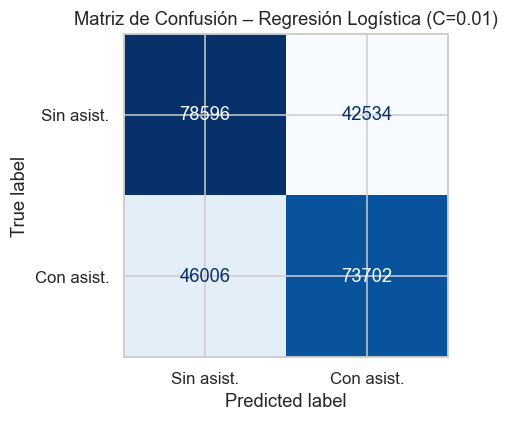

In [57]:
# -- Modelo final LR --
best_c = df_lr.loc[df_lr['auc_test'].idxmax(), 'C']
lr_final = LogisticRegression(C=best_c, max_iter=1000, random_state=42,
                               class_weight='balanced', solver='lbfgs')
r = evaluar_modelo(f'Regresión Logística (C={best_c})',
                   lr_final, X_train_sc, y_train, X_test_sc, y_test)
resultados.append(r)


## 11. Comparación de modelos y curvas ROC

In [58]:
# Tabla resumen
df_res = pd.DataFrame([{
    'Modelo'     : r['modelo'],
    'Accuracy'   : f"{r['accuracy']:.4f}",
    'AUC-ROC'    : f"{r['auc']:.4f}" if r['auc'] else 'N/A',
    'CV-Accuracy': f"{r['cv_accuracy']:.4f}"
} for r in resultados])

print(df_res.to_string(index=False))


                         Modelo Accuracy AUC-ROC CV-Accuracy
    Árbol de Decisión (depth=5)   0.8637  0.9056      0.8642
Random Forest (n=100, depth=10)   0.8685  0.9256      0.8675
   Regresión Logística (C=0.01)   0.6324  0.6869      0.6322


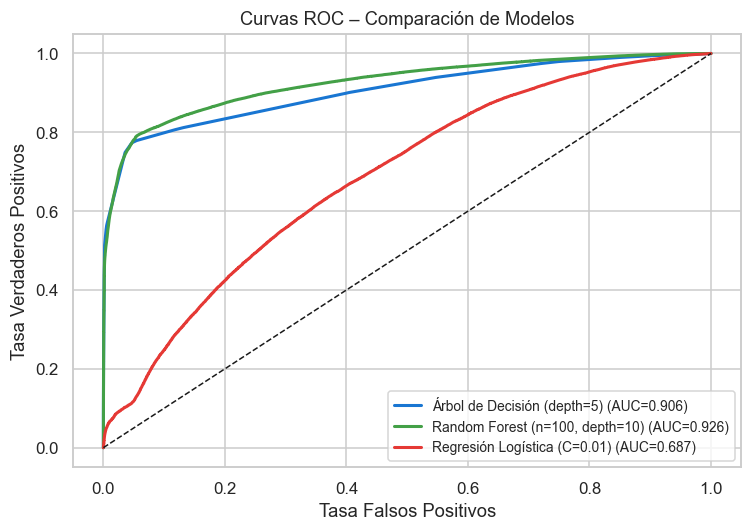

In [59]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 5))
colores = ['#1976D2', '#43A047', '#E53935']
for r, color in zip(resultados, colores):
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{r['modelo']} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('Tasa Falsos Positivos')
ax.set_ylabel('Tasa Verdaderos Positivos')
ax.set_title('Curvas ROC – Comparación de Modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## 12. Selección del mejor modelo y conclusiones
El modelo con mayor AUC-ROC y accuracy balanceado se selecciona como **modelo final**.


In [60]:
mejor = max(resultados, key=lambda r: r['auc'] if r['auc'] else 0)
print(f"🏆 Mejor modelo: {mejor['modelo']}")
print(f"   Accuracy : {mejor['accuracy']:.4f}")
print(f"   AUC-ROC  : {mejor['auc']:.4f}")
print(f"   CV-Acc   : {mejor['cv_accuracy']:.4f}")


🏆 Mejor modelo: Random Forest (n=100, depth=10)
   Accuracy : 0.8685
   AUC-ROC  : 0.9256
   CV-Acc   : 0.8675


### Conclusiones
- Se predijo exitosamente la variable `asis_med` (recibió o no asistencia médica) con 802,793 registros.
- Las clases estuvieron casi perfectamente balanceadas (49.7% con asistencia / 50.3% sin asistencia), por lo que no fue necesario aplicar técnicas de balanceo como SMOTE.
- **Random Forest (n=100, depth=10)** fue el mejor modelo con Accuracy=0.8685 y AUC-ROC=0.9256, superando al Árbol de Decisión y a la Regresión Logística.
- **Árbol de Decisión (depth=5)** obtuvo resultados muy competitivos (Accuracy=0.8637, AUC-ROC=0.9056) con mucho menor costo computacional, siendo una alternativa viable.
- **Regresión Logística** tuvo un rendimiento notablemente inferior (Accuracy=0.6324, AUC-ROC=0.6869), lo que sugiere que la relación entre las variables predictoras y la asistencia médica no es lineal.
- Las variables más relevantes en el modelo final fueron `causa_capitulo`, `ocur`, `perdif`, `depocu` y `edad_anios`, reflejando que el tipo de muerte, lugar de ocurrencia y edad son determinantes del acceso a asistencia médica en Guatemala.
- Para trabajo futuro se recomienda explorar **XGBoost** o **LightGBM** y agregar `areag` una vez resueltos los valores faltantes, ya que el área geográfica es una variable clave en el acceso a salud.